<a href="https://colab.research.google.com/github/RonenVainer/HIT-ML-Assignment/blob/main/ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">
<h1>
מטלה - למידת מכונה
</h1>

מגישים:
* יוסי אריאל - ת"ז 7842
* רונן ויינר - ת"ז 1751
* אוריאן מויאל - ת"ז 8977
</div>


---

### Part 1 - Introduction and Dataset Loading


<div dir="rtl">

דוגמאות לפרומפטים שבהם השתמשנו:

* איך אפשר לבחור את מספר השכנים המתאים ביותר ל-KNN ולא להסתמך על ערך שבחרנו ידנית?
* תראה איך לבצע Grid Search עם 5-Fold Cross Validation עבור KNN, ותסביר מה כל שלב בקוד עושה.
* אחרי שאימנו את המודל וקיבלנו תוצאות, איך נכון לנתח אותן ולהבין איפה המודל מצליח ואיפה הוא מתקשה?
* אנחנו רוצים לבחון HOG כ-Feature Engineering נוסף לתמונות. תסביר מה הוא מייצג ואיך להשוות אותו בצורה הוגנת ל-Feature Engineering שנלמד בקורס.

מטרות השימוש ב-AI:
* הבנה והכוונה לאורך העבודה - חידוד מושגים והבנת השלבים הנדרשים בתהליך.
* סיוע בכתיבת הקוד - בניית קטעי קוד בהתאם לשלבים שתכננו, תוך מעבר ובדיקה שלנו על הקוד.
* ניתוח והסקת מסקנות - עזרה בפירוש התוצאות ובהבנת הסיבות האפשריות להתנהגות המודלים.

ה-AI שימש ככלי עזר להסבר, הכוונה וכתיבת קוד. כל קטע קוד שהוצע נבדק והורץ על ידינו, תוך הבנת אופן פעולתו ובחינת התאמתו למטלה.
</div>


<div dir="rtl">

הסבר על בעיית הלמידה וה-Dataset:

בחרנו לעסוק בבעיית סיווג תמונות באמצעות מאגר הנתונים Fashion-MNIST. המאגר מכיל 70,000 תמונות בגווני אפור בגודל 28x28 פיקסלים, המחולקות ל-10 קטגוריות של פריטי לבוש, כגון חולצות, מכנסיים, שמלות, נעליים ותיקים. כל תמונה מיוצגת באמצעות 784 ערכי פיקסלים בטווח 0-255. מטרת הפרויקט היא לבנות מודל סיווג רב-מחלקתי (Multi-Class Classification), אשר יקבל ייצוג של תמונה ויחזה לאיזו קטגוריית לבוש היא שייכת. המאגר כולל פיצול מובנה של 60,000 תמונות לאימון ו-10,000 תמונות לבדיקה, כאשר מחלקות האימון מאוזנות וכוללות 6,000 תמונות מכל קטגוריה.

מקור הנתונים: https://www.kaggle.com/datasets/zalando-research/fashionmnist

בחירת האלגוריתם:

בחרנו באלגוריתם KNN (K-Nearest Neighbors) מכיוון שהוא אלגוריתם סיווג פשוט ואינטואיטיבי, המתאים גם לבעיות סיווג רב-מחלקתיות כמו Fashion-MNIST. האלגוריתם מסווג כל תמונה לפי הדוגמאות הדומות לה ביותר, ולכן מאפשר לבחון בצורה ברורה כיצד ייצוג התמונה, מספר השכנים ושיטת ההצבעה משפיעים על איכות הסיווג.
</div>


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
train_df = pd.read_csv('/content/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/fashion-mnist_test.csv')

y_train = train_df['label'].to_numpy()
X_train = train_df.drop(columns='label').to_numpy(dtype=np.float32)

y_test = test_df['label'].to_numpy()
X_test = test_df.drop(columns='label').to_numpy(dtype=np.float32)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("pixel value range:", X_train.min(), "-", X_train.max())


X_train: (60000, 784) | y_train: (60000,)
X_test : (10000, 784) | y_test : (10000,)
pixel value range: 0.0 - 255.0


In [ ]:
print("TRAIN - first 5 rows:")
display(train_df.head())

print("TEST - first 5 rows:")
display(test_df.head())


TRAIN - first 5 rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


TEST - first 5 rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div dir="rtl">
<h3>
בחירת מדד האיכות:
</h3>

בחרנו במדד Macro-Average F1, מכיוון שמדובר בבעיית סיווג רב-מחלקתית ללא מחלקה מרכזית אחת. המדד מחשב F1 לכל אחת מ-10 המחלקות בנפרד ולאחר מכן מבצע ממוצע ביניהן, כך שכל קטגוריית לבוש מקבלת חשיבות שווה בהערכת ביצועי המודל.
</div>


0  T-shirt/top  6000
1  Trouser      6000
2  Pullover     6000
3  Dress        6000
4  Coat         6000
5  Sandal       6000
6  Shirt        6000
7  Sneaker      6000
8  Bag          6000
9  Ankle boot   6000


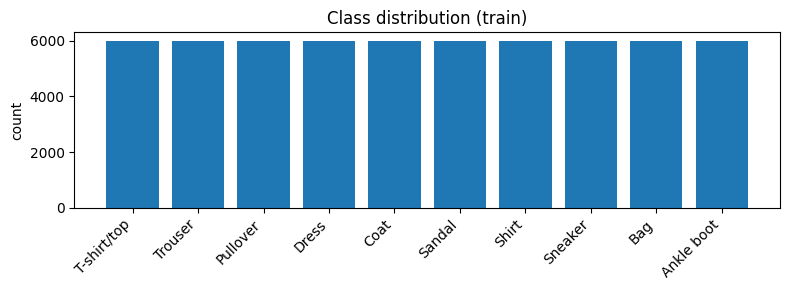

In [ ]:
# Count how many training examples belong to each class
counts = pd.Series(y_train).value_counts().sort_index()

for k, v in counts.items():
    print(f"{k}  {CLASS_NAMES[k]:<12} {v}")

plt.figure(figsize=(8, 3))
plt.bar(range(10), counts.values)
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.title('Class distribution (train)')
plt.ylabel('count')
plt.tight_layout()
plt.show()


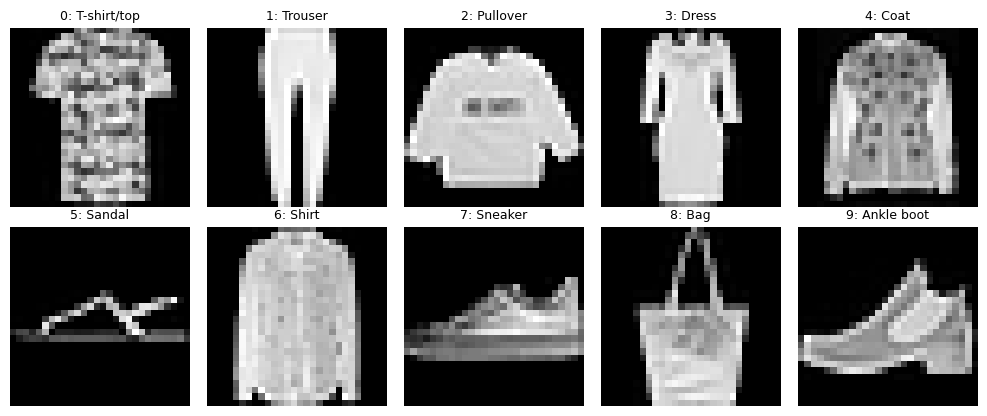

In [ ]:
# Show one example image from each class
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))

for cls, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_train == cls)[0][0]
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{cls}: {CLASS_NAMES[cls]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


---

### Part 2 - Feature Engineering


<div dir="rtl">
<h3>
Feature Engineering 1 - Standardization
</h3>

ביצענו Standardization לכל אחד מ-784 מאפייני הפיקסלים באמצעות הממוצע וסטיית התקן שנלמדו מנתוני ה-train. פעולה זו מביאה את המאפיינים לסקאלה משותפת, דבר החשוב במיוחד עבור KNN המבוסס על מרחקים. את ה-fit ביצענו רק על נתוני האימון, ואת אותה טרנספורמציה החלתנו על נתוני ה-test כדי למנוע Data Leakage.
</div>


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("Before standardization:")
print("  mean =", round(float(X_train.mean()), 3))
print("  std  =", round(float(X_train.std()), 3))

print("\nAfter standardization:")
print("  mean =", round(float(X_train_std.mean()), 3))
print("  std  =", round(float(X_train_std.std()), 3))


Before standardization:
  mean = 72.957
  std  = 89.967

After standardization:
  mean = -0.0
  std  = 1.0


--- TRAIN example 1 (index 0) ---
raw : [100. 121. 147. 221. 230.]
std : [-0.469 -0.447 -0.111  1.296  1.256]


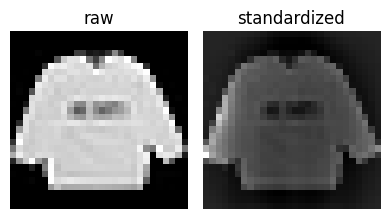

--- TRAIN example 2 (index 1) ---
raw : [168. 147. 119.   0.   0.]
std : [ 0.396 -0.087 -0.508 -1.168 -1.435]


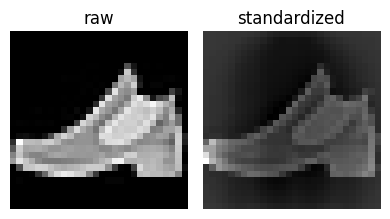

--- TEST example 1 (index 0) ---
raw : [186. 192. 210. 226. 145.]
std : [0.625 0.534 0.781 1.352 0.261]


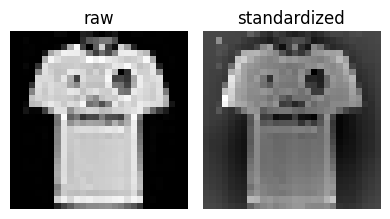

In [ ]:
def show_standardization_example(X_raw, X_std, idx, title):
    sample_pixels = [350, 351, 352, 400, 401]

    print(f"--- {title} (index {idx}) ---")
    print("raw :", np.round(X_raw[idx, sample_pixels], 3))
    print("std :", np.round(X_std[idx, sample_pixels], 3))

    fig, ax = plt.subplots(1, 2, figsize=(4, 2.2))
    ax[0].imshow(X_raw[idx].reshape(28, 28), cmap='gray')
    ax[0].set_title('raw')
    ax[0].axis('off')

    ax[1].imshow(X_std[idx].reshape(28, 28), cmap='gray')
    ax[1].set_title('standardized')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

# 2 train examples and 1 test example
show_standardization_example(X_train, X_train_std, 0, "TRAIN example 1")
show_standardization_example(X_train, X_train_std, 1, "TRAIN example 2")
show_standardization_example(X_test, X_test_std, 0, "TEST example 1")


<div dir="rtl">
<h3>
Feature Engineering 2 - הורדת ממד (PCA)
</h3>

לאחר ה-Standardization השתמשנו ב-PCA כדי לצמצם כל תמונה מ-784 מאפיינים ל-50 רכיבים עיקריים. המטרה היא ליצור ייצוג קומפקטי יותר ולשמור ככל האפשר על המבנה המרכזי של הנתונים. גם כאן ביצענו fit רק על נתוני ה-train ולאחר מכן transform על נתוני ה-train וה-test.
</div>


X_train_std: (60000, 784) -> X_train_pca: (60000, 50)
X_test_std : (10000, 784) -> X_test_pca : (10000, 50)
variance kept by 50 components: 0.800


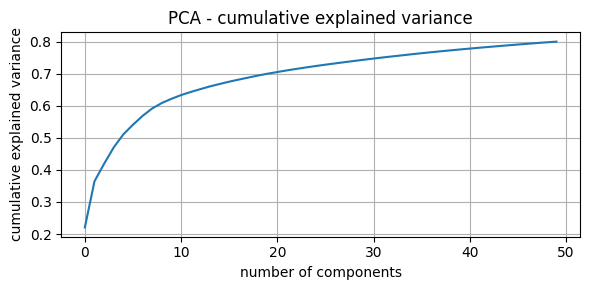

In [ ]:
from sklearn.decomposition import PCA

N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(X_train_std)

X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print("X_train_std:", X_train_std.shape, "-> X_train_pca:", X_train_pca.shape)
print("X_test_std :", X_test_std.shape,  "-> X_test_pca :", X_test_pca.shape)

var_kept = pca.explained_variance_ratio_.sum()
print(f"variance kept by {N_COMPONENTS} components: {var_kept:.3f}")

plt.figure(figsize=(6, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('PCA - cumulative explained variance')
plt.grid(True)
plt.tight_layout()
plt.show()


--- TRAIN example 1 (index 0) ---
reduced vector - first 5 components: [ 10.665  14.993  -0.689 -10.981   4.788]


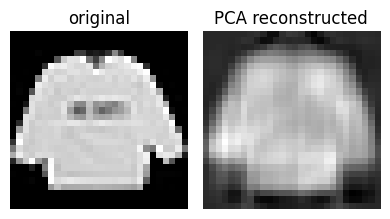

--- TRAIN example 2 (index 1) ---
reduced vector - first 5 components: [-11.99   11.813  -5.801  -3.419  -4.631]


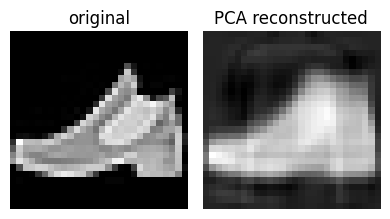

--- TEST example 1 (index 0) ---
reduced vector - first 5 components: [15.981 -4.598 -1.13   1.201  7.786]


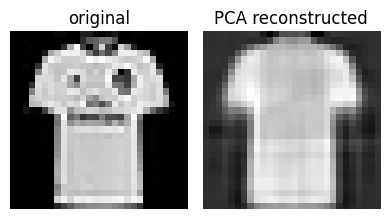

In [ ]:
def show_pca_example(X_raw, X_std, idx, title):
    z = pca.transform(X_std[idx:idx+1])

    reconstructed_std = pca.inverse_transform(z)
    reconstructed_raw = scaler.inverse_transform(reconstructed_std)

    print(f"--- {title} (index {idx}) ---")
    print("reduced vector - first 5 components:", np.round(z[0, :5], 3))

    fig, ax = plt.subplots(1, 2, figsize=(4, 2.2))
    ax[0].imshow(X_raw[idx].reshape(28, 28), cmap='gray')
    ax[0].set_title('original')
    ax[0].axis('off')

    ax[1].imshow(reconstructed_raw.reshape(28, 28), cmap='gray')
    ax[1].set_title('PCA reconstructed')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

# 2 train examples and 1 test example
show_pca_example(X_train, X_train_std, 0, "TRAIN example 1")
show_pca_example(X_train, X_train_std, 1, "TRAIN example 2")
show_pca_example(X_test, X_test_std, 0, "TEST example 1")


---

### Part 3 - KNN Implementation

<div dir="rtl">

מימוש KNN

מימשנו את אלגוריתם KNN מאפס באמצעות המחלקה KNNClassifier. בשלב ה-fit נשמרים נתוני האימון, ובשלב ה-predict מחושבים המרחקים בין כל דוגמה חדשה לדוגמאות האימון ונבחרים k השכנים הקרובים ביותר.

לצורך חישוב יעיל של המרחק האוקלידי, השתמשנו בחישוב וקטורי המבוסס על הזהות:

$$
\|a-t\|^2 = \|a\|^2 - 2(a \cdot t) + \|t\|^2
$$

כך ניתן לחשב את המרחקים באמצעות פעולות על מטריצות במקום לעבור בלולאה על כל זוג דוגמאות. לאחר חישוב המרחקים, argpartition משמש למציאת k השכנים הקרובים ביותר ללא צורך במיון מלא של כל המרחקים.

הסיווג נקבע לפי ה-hyperparameter weights:
* ב-uniform לכל שכן יש משקל זהה בהצבעה.
* ב-distance לשכנים קרובים יותר ניתנת השפעה גדולה יותר.


</div>


In [ ]:
class KNNClassifier:
    def __init__(self, k=5, weights='uniform'):
        self.k = k
        self.weights = weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        self.n_classes = int(y.max()) + 1
        return self

    def predict(self, X, batch_size=500):
        preds = []
        train_sq = np.sum(self.X_train**2, axis=1)[None, :]

        for start in range(0, len(X), batch_size):
            batch = X[start:start + batch_size]

            dists = (
                np.sum(batch**2, axis=1)[:, None]
                + train_sq
                - 2 * batch @ self.X_train.T
            )
            dists = np.maximum(dists, 0)

            knn_idx = np.argpartition(
                dists, self.k - 1, axis=1
            )[:, :self.k]

            rows = np.arange(len(batch))[:, None]
            knn_labels = self.y_train[knn_idx]
            knn_dists = dists[rows, knn_idx]

            if self.weights == 'uniform':
                weights = np.ones_like(knn_dists)
            else:
                weights = 1.0 / (np.sqrt(knn_dists) + 1e-8)

            vote = np.zeros((len(batch), self.n_classes))

            for j in range(self.k):
                vote[rows[:, 0], knn_labels[:, j]] += weights[:, j]

            preds.append(vote.argmax(axis=1))

        return np.concatenate(preds)


---

### Part 4 - Initial KNN Training

<div dir="rtl">

בשלב זה אימנו מודל בסיסי באמצעות ה-Feature Engineering מחלק 2: Standardization ולאחריו PCA עם 50 רכיבים. לצורך האימון הראשוני השתמשנו ב-k=5 ובהצבעה לפי distance. בחלק 6א נבצע בחירה שיטתית יותר של ה-Feature Engineering וה-hyperparameters באמצעות Cross Validation.
</div>


In [ ]:
knn = KNNClassifier(
    k=5,
    weights='distance'
).fit(X_train_pca, y_train)

print("Initial KNN trained:")
print("  representation = standardized pixels")
print("  PCA components = 50")
print("  k              = 5")
print("  weights        = distance")


Initial KNN trained:
  representation = standardized pixels
  PCA components = 50
  k              = 5
  weights        = distance


---

### Part 5 - Prediction and Model Evaluation

<div dir="rtl">

לאחר האימון הראשוני ביצענו חיזוי על נתוני ה-test והשווינו את התחזיות לערכים האמיתיים. הצגנו את חמשת החיזויים הראשונים והערכנו את ביצועי המודל באמצעות Macro-F1, לצד Accuracy ו-Classification Report. בנוסף, הצגנו Confusion Matrix כדי לבחון באילו מחלקות המודל מצליח ובאילו הוא נוטה להתבלבל.
</div>


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = knn.predict(X_test_pca)

print("first 5 predictions:", y_pred[:5])
print("first 5 true labels:", y_test[:5])

acc_initial = accuracy_score(y_test, y_pred)
f1_initial = f1_score(y_test, y_pred, average='macro')

print("\naccuracy :", round(acc_initial, 4))
print("macro-F1 :", round(f1_initial, 4))

print("\nper-class report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=3
))


first 5 predictions: [0 1 2 2 3]
first 5 true labels: [0 1 2 2 3]

accuracy : 0.8598
macro-F1 : 0.8599

per-class report:
              precision    recall  f1-score   support

 T-shirt/top      0.795     0.820     0.807      1000
     Trouser      0.989     0.969     0.979      1000
    Pullover      0.807     0.758     0.782      1000
       Dress      0.891     0.894     0.893      1000
        Coat      0.765     0.809     0.786      1000
      Sandal      0.961     0.884     0.921      1000
       Shirt      0.643     0.637     0.640      1000
     Sneaker      0.889     0.912     0.900      1000
         Bag      0.976     0.961     0.968      1000
  Ankle boot      0.895     0.954     0.924      1000

    accuracy                          0.860     10000
   macro avg      0.861     0.860     0.860     10000
weighted avg      0.861     0.860     0.860     10000



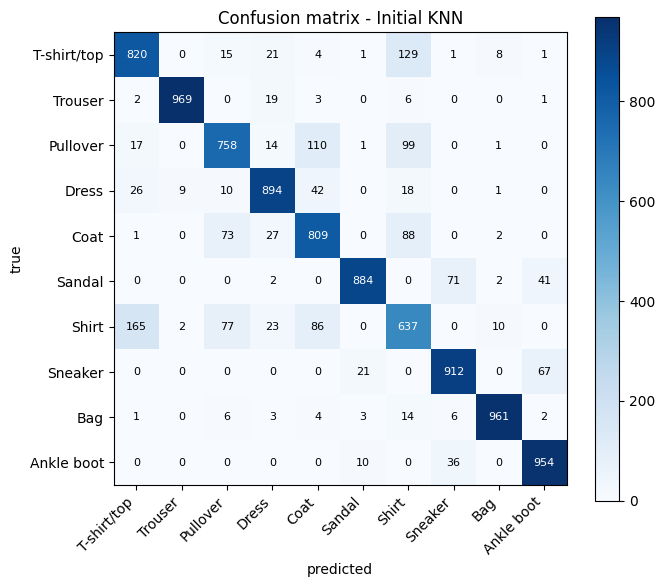

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(10))
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('Confusion matrix - Initial KNN')

for i in range(10):
    for j in range(10):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > cm.max()/2 else 'black',
            fontsize=8
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()


<div dir="rtl">

ה-Confusion Matrix מאפשר לזהות אילו מחלקות מסווגות היטב ואילו מחלקות נוטות להתבלבל זו עם זו. בפרט, מחלקות של פריטי לבוש בעלי מבנה חזותי דומה עשויות להיות קשות יותר להפרדה באמצעות מרחק בלבד. בהמשך נבדוק האם ייצוג תמונה מתקדם יותר באמצעות HOG יכול לשפר את איכות הסיווג.
</div>


---

### Part 6a - Feature Engineering, Grid Search and 5-Fold Cross Validation


<div dir="rtl">

בחלק זה הרחבנו את תהליך בחירת המודל בצורה שיטתית.

תחילה השווינו בין שתי דרכים לייצג את התמונה:
* Pixels - 784 ערכי הפיקסלים המקוריים של התמונה.
* HOG - ייצוג מתקדם יותר שמדגיש קצוות, כיוונים ומבנה מקומי בתמונה.

לאחר מכן השווינו מספר אפשרויות של PCA, ולבסוף בחנו כיצד מספר השכנים k ושיטת ההצבעה משפיעים על הביצועים.

כל הקומבינציות נבדקות באמצעות 5-Fold Cross Validation על נתוני ה-train בלבד. בכל fold ה-StandardScaler וה-PCA מבצעים fit רק על חלק האימון של אותו fold, כדי למנוע Data Leakage.

לצורך שמירה על זמן ריצה סביר, ה-Grid Search מתבצע על מדגם אקראי של 12,000 דוגמאות מתוך ה-train. לאחר בחירת הקומבינציה הטובה ביותר, המודל הסופי יאומן מחדש על כל 60,000 דוגמאות האימון.
</div>


<div dir="rtl">
<h3>
HOG - Histogram of Oriented Gradients
</h3>

HOG מתאר את המבנה המקומי של התמונה באמצעות עוצמת וכיוון ה-gradients. במקום להשתמש רק בערכי הפיקסלים עצמם, הוא מדגיש קצוות, צורות וכיוונים ולכן עשוי לייצג טוב יותר פריטי לבוש.

השתמשנו ב-9 כיוונים, תאים בגודל 4x4 פיקסלים ובלוקים של 2x2 תאים.
</div>


In [ ]:
from skimage.feature import hog

HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (4, 4),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys'
}

def extract_hog_features(X):
    features = []
    for image in X:
        image_2d = image.reshape(28, 28)
        feature_vector = hog(
            image_2d,
            orientations=HOG_PARAMS['orientations'],
            pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
            cells_per_block=HOG_PARAMS['cells_per_block'],
            block_norm=HOG_PARAMS['block_norm']
        )
        features.append(feature_vector)
    return np.asarray(features, dtype=np.float32)


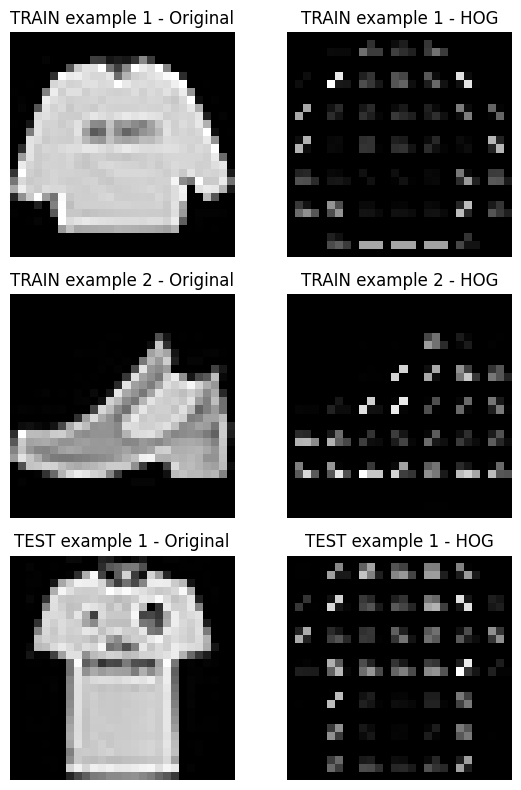

In [ ]:
# Show HOG on 2 train examples and 1 test example
examples = [
    (X_train, 0, "TRAIN example 1"),
    (X_train, 1, "TRAIN example 2"),
    (X_test, 0, "TEST example 1")
]

fig, axes = plt.subplots(3, 2, figsize=(6, 8))
for row, (X_source, idx, title) in enumerate(examples):
    image = X_source[idx].reshape(28, 28)
    _, hog_image = hog(
        image,
        orientations=HOG_PARAMS['orientations'],
        pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
        cells_per_block=HOG_PARAMS['cells_per_block'],
        block_norm=HOG_PARAMS['block_norm'],
        visualize=True
    )
    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].set_title(title + " - Original")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(hog_image, cmap='gray')
    axes[row, 1].set_title(title + " - HOG")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


<div dir="rtl">

ב-Grid Search בדקנו את כל השילובים הבאים:

* Representation: Pixels או HOG.
* PCA: 50, 100 או 200 רכיבים.
* k: כל הערכים האי-זוגיים מ-1 עד 31.
* weights: uniform או distance.

למרות שההצגה במחברת תהיה לפי שלבים, הבחירה הסופית מבוססת על Grid Search מלא של כל הקומבינציות.
</div>


In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score

representation_grid = ['pixels', 'hog']
pca_grid = [50, 100, 200]
k_grid = list(range(1, 32, 2))
weights_grid = ['uniform', 'distance']

N_SUB = 12000
rng_search = np.random.RandomState(RANDOM_STATE)
sub_idx = rng_search.permutation(len(X_train))[:N_SUB]

X_search_raw = X_train[sub_idx]
y_search = y_train[sub_idx]

# HOG is deterministic and does not learn parameters from the data,
# so it can be precomputed before Cross Validation without leakage.
print("Extracting HOG features for the Grid Search sample...")
X_search_hog = extract_hog_features(X_search_raw)

print("Raw pixel shape:", X_search_raw.shape)
print("HOG shape      :", X_search_hog.shape)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(kf.split(X_search_raw))


Extracting HOG features for the Grid Search sample...
Raw pixel shape: (12000, 784)
HOG shape      : (12000, 1296)


<div dir="rtl">

כדי לייעל את הבדיקה של k, אנו מחשבים בכל fold את 31 השכנים הקרובים פעם אחת בלבד. לאחר מכן ניתן להשתמש באותם שכנים כדי לבדוק את כל ערכי k האי-זוגיים מ-1 עד 31, בלי לחשב מחדש את כל המרחקים בכל פעם.
</div>


In [ ]:
def get_nearest_neighbors(X_tr, y_tr, X_val, max_k, batch_size=500):
    all_labels = []
    all_distances = []
    train_sq = np.sum(X_tr**2, axis=1)[None, :]

    for start in range(0, len(X_val), batch_size):
        batch = X_val[start:start + batch_size]
        dists_sq = (
            np.sum(batch**2, axis=1)[:, None]
            + train_sq
            - 2 * batch @ X_tr.T
        )
        dists_sq = np.maximum(dists_sq, 0)
        idx = np.argpartition(dists_sq, max_k - 1, axis=1)[:, :max_k]
        rows = np.arange(len(batch))[:, None]
        order = np.argsort(dists_sq[rows, idx], axis=1)
        idx = np.take_along_axis(idx, order, axis=1)
        dists = np.sqrt(dists_sq[rows, idx])
        all_labels.append(y_tr[idx])
        all_distances.append(dists)

    return np.concatenate(all_labels, axis=0), np.concatenate(all_distances, axis=0)


def predict_from_neighbors(neighbor_labels, neighbor_distances, k, weights, n_classes=10):
    labels = neighbor_labels[:, :k]
    distances = neighbor_distances[:, :k]

    if weights == 'uniform':
        vote_weights = np.ones_like(distances)
    else:
        vote_weights = 1.0 / (distances + 1e-8)

    votes = np.zeros((len(labels), n_classes))
    for j in range(k):
        votes[np.arange(len(labels)), labels[:, j]] += vote_weights[:, j]
    return votes.argmax(axis=1)


In [ ]:
score_store = {}

for representation in representation_grid:
    X_rep = X_search_raw if representation == 'pixels' else X_search_hog

    for n_comp in pca_grid:
        print(f"Processing representation={representation}, PCA={n_comp}")

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            X_tr_raw = X_rep[train_idx]
            X_val_raw = X_rep[val_idx]
            y_tr = y_search[train_idx]
            y_val = y_search[val_idx]

            scaler_cv = StandardScaler()
            X_tr_std = scaler_cv.fit_transform(X_tr_raw)
            X_val_std = scaler_cv.transform(X_val_raw)

            pca_cv = PCA(n_components=n_comp, random_state=RANDOM_STATE)
            X_tr_pca = pca_cv.fit_transform(X_tr_std)
            X_val_pca = pca_cv.transform(X_val_std)

            neighbor_labels, neighbor_distances = get_nearest_neighbors(
                X_tr_pca, y_tr, X_val_pca, max_k=max(k_grid)
            )

            for k in k_grid:
                for w in weights_grid:
                    pred = predict_from_neighbors(
                        neighbor_labels, neighbor_distances, k=k, weights=w
                    )
                    score = f1_score(y_val, pred, average='macro')
                    key = (representation, n_comp, k, w)
                    score_store.setdefault(key, []).append(score)

results = []
for (representation, n_comp, k, w), scores in score_store.items():
    results.append({
        'representation': representation,
        'pca_n': n_comp,
        'k': k,
        'weights': w,
        'cv_macro_f1': np.mean(scores),
        'std': np.std(scores)
    })

print("Finished", len(results), "combinations x 5 folds")


Processing representation=pixels, PCA=50
Processing representation=pixels, PCA=100
Processing representation=pixels, PCA=200
Processing representation=hog, PCA=50
Processing representation=hog, PCA=100
Processing representation=hog, PCA=200
Finished 192 combinations x 5 folds


In [ ]:
results_df = (
    pd.DataFrame(results)
    .sort_values('cv_macro_f1', ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

best = results_df.iloc[0]
print("BEST combination:")
print(f"  representation = {best['representation']}")
print(f"  PCA components = {int(best['pca_n'])}")
print(f"  k              = {int(best['k'])}")
print(f"  weights        = {best['weights']}")
print(f"  CV macro-F1    = {best['cv_macro_f1']:.4f}")


,representation,pca_n,k,weights,cv_macro_f1,std
0,hog,50,15,distance,0.8660,0.0068
1,hog,50,17,distance,0.8659,0.0069
2,hog,50,9,distance,0.8651,0.0048
3,hog,50,15,uniform,0.8651,0.0064
4,hog,50,17,uniform,0.8647,0.0070
...,...,...,...,...,...,...
187,pixels,200,29,uniform,0.8159,0.0083
188,pixels,200,31,uniform,0.8153,0.0096
189,pixels,50,31,uniform,0.8147,0.0046
190,pixels,50,1,uniform,0.8093,0.0039


BEST combination:
  representation = hog
  PCA components = 50
  k              = 15
  weights        = distance
  CV macro-F1    = 0.8660


<div dir="rtl">
<h3>
שלב 1 - השוואת Pixels מול HOG
</h3>

בשלב הראשון בחנו איזו דרך לייצג את התמונה נותנת את הביצועים הטובים יותר. עבור כל representation לקחנו את תוצאת ה-Cross Validation הטובה ביותר שהתקבלה מכל הקומבינציות של PCA, k ו-weights.
</div>


,representation,cv_macro_f1
0,hog,0.8660
1,pixels,0.8357


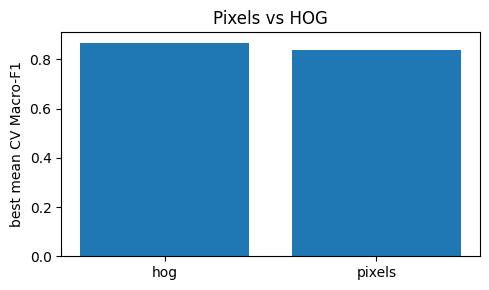

In [ ]:
representation_summary = (
    results_df
    .groupby('representation', as_index=False)['cv_macro_f1']
    .max()
    .sort_values('cv_macro_f1', ascending=False)
)

display(representation_summary.round(4))

plt.figure(figsize=(5, 3))
plt.bar(representation_summary['representation'], representation_summary['cv_macro_f1'])
plt.ylabel('best mean CV Macro-F1')
plt.title('Pixels vs HOG')
plt.tight_layout()
plt.show()


<div dir="rtl">
<h3>
שלב 2 - השוואת מספר רכיבי PCA
</h3>

לאחר מכן בחנו כיצד מספר רכיבי ה-PCA משפיע על כל אחת מדרכי הייצוג. כך ניתן לראות האם צמצום חזק מדי של הממד מאבד מידע, והאם הגדלת מספר הרכיבים ממשיכה לתרום.
</div>


,representation,pca_n,cv_macro_f1
0,hog,50,0.8660
1,hog,100,0.8617
2,hog,200,0.8546
3,pixels,50,0.8298
4,pixels,100,0.8332
5,pixels,200,0.8357


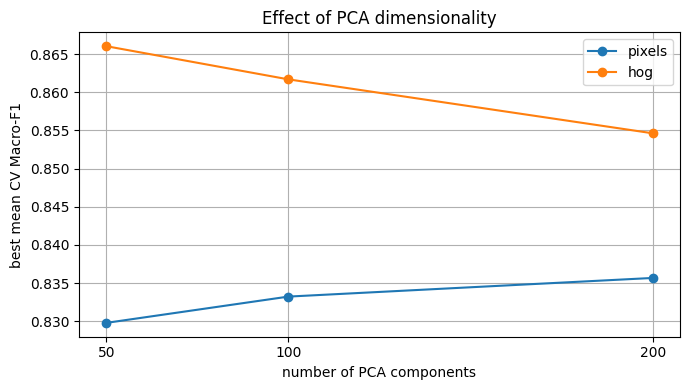

In [ ]:
pca_summary = (
    results_df
    .groupby(['representation', 'pca_n'], as_index=False)['cv_macro_f1']
    .max()
)

display(pca_summary.sort_values(['representation', 'pca_n']).round(4))

plt.figure(figsize=(7, 4))
for representation in representation_grid:
    part = pca_summary[pca_summary['representation'] == representation]
    plt.plot(part['pca_n'], part['cv_macro_f1'], marker='o', label=representation)

plt.xlabel('number of PCA components')
plt.ylabel('best mean CV Macro-F1')
plt.title('Effect of PCA dimensionality')
plt.xticks(pca_grid)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<div dir="rtl">
<h3>
שלב 3 - השפעת k על המודל
</h3>

כעת בחרנו את ה-representation, מספר רכיבי ה-PCA ושיטת ההצבעה מתוך הקומבינציה המובילה, והשארנו רק את k כמשתנה.

הגרף מציג את Mean Macro-F1 של 5-Fold CV עבור כל ערך k מ-1 עד 31. כך ניתן לראות האם הביצועים ממשיכים להשתפר ככל שמגדילים את מספר השכנים, או שמגיעים לנקודה שבה השיפור מתייצב ואף מתחיל לרדת.
</div>


,representation,pca_n,k,weights,cv_macro_f1,std
91,hog,50,1,distance,0.8417,0.0059
47,hog,50,3,distance,0.8586,0.0084
6,hog,50,5,distance,0.8639,0.0043
10,hog,50,7,distance,0.8636,0.0057
2,hog,50,9,distance,0.8651,0.0048
7,hog,50,11,distance,0.8639,0.0062
9,hog,50,13,distance,0.8638,0.0054
0,hog,50,15,distance,0.8660,0.0068
1,hog,50,17,distance,0.8659,0.0069
11,hog,50,19,distance,0.8636,0.0061


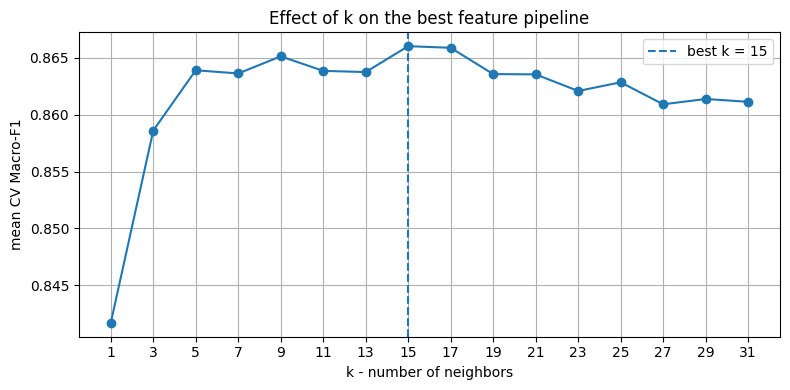

In [ ]:
best_representation = best['representation']
best_pca = int(best['pca_n'])
best_weights = best['weights']

k_curve = (
    results_df[
        (results_df['representation'] == best_representation) &
        (results_df['pca_n'] == best_pca) &
        (results_df['weights'] == best_weights)
    ]
    .sort_values('k')
)

display(k_curve[['representation', 'pca_n', 'k', 'weights', 'cv_macro_f1', 'std']].round(4))

plt.figure(figsize=(8, 4))
plt.plot(k_curve['k'], k_curve['cv_macro_f1'], marker='o')
plt.axvline(int(best['k']), linestyle='--', label=f"best k = {int(best['k'])}")
plt.xlabel('k - number of neighbors')
plt.ylabel('mean CV Macro-F1')
plt.title('Effect of k on the best feature pipeline')
plt.xticks(k_grid)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<div dir="rtl">
<h3>
שלב 4 - השוואת weights ובחירת הקומבינציה הסופית
</h3>

לבסוף השווינו בין uniform ל-distance ובחרנו את הקומבינציה בעלת Mean Macro-F1 הגבוה ביותר בכלל ה-Grid Search.

הבחירה הסופית מתבצעת לפי תוצאות ה-Cross Validation בלבד. נתוני ה-test אינם משתתפים בבחירת ה-hyperparameters ומשמשים רק לאחר מכן להערכת המודל הסופי.
</div>


In [ ]:
weights_summary = (
    results_df
    .groupby('weights', as_index=False)['cv_macro_f1']
    .max()
    .sort_values('cv_macro_f1', ascending=False)
)

display(weights_summary.round(4))

print("FINAL CV SELECTION:")
print(f"  representation = {best['representation']}")
print(f"  PCA components = {int(best['pca_n'])}")
print(f"  k              = {int(best['k'])}")
print(f"  weights        = {best['weights']}")
print(f"  CV macro-F1    = {best['cv_macro_f1']:.4f}")


,weights,cv_macro_f1
0,distance,0.8660
1,uniform,0.8651


FINAL CV SELECTION:
  representation = hog
  PCA components = 50
  k              = 15
  weights        = distance
  CV macro-F1    = 0.8660


---

### Final Training After Grid Search

<div dir="rtl">

לאחר בחירת השילוב הטוב ביותר ב-Grid Search, בנינו מחדש את כל ה-pipeline על מלוא נתוני ה-train. תחילה נוצר ייצוג התמונה שנבחר, לאחר מכן בוצעו Standardization ו-PCA עם הפרמטרים שנבחרו, ולבסוף אומן KNN עם k ושיטת ההצבעה שנבחרו ב-Cross Validation.
</div>


In [ ]:
FINAL_REPRESENTATION = best['representation']
FINAL_PCA_N = int(best['pca_n'])
FINAL_K = int(best['k'])
FINAL_WEIGHTS = best['weights']

print("Final configuration:")
print(f"  representation = {FINAL_REPRESENTATION}")
print(f"  PCA components = {FINAL_PCA_N}")
print(f"  k              = {FINAL_K}")
print(f"  weights        = {FINAL_WEIGHTS}")

if FINAL_REPRESENTATION == 'hog':
    print("\nExtracting HOG features for the full train and test sets...")
    X_train_rep_final = extract_hog_features(X_train)
    X_test_rep_final = extract_hog_features(X_test)
else:
    X_train_rep_final = X_train
    X_test_rep_final = X_test

scaler_final = StandardScaler()
X_train_final_std = scaler_final.fit_transform(X_train_rep_final)
X_test_final_std = scaler_final.transform(X_test_rep_final)

pca_final = PCA(
    n_components=FINAL_PCA_N,
    random_state=RANDOM_STATE
)

X_train_final = pca_final.fit_transform(X_train_final_std)
X_test_final = pca_final.transform(X_test_final_std)

knn_final = KNNClassifier(
    k=FINAL_K,
    weights=FINAL_WEIGHTS
).fit(X_train_final, y_train)

print("\nFinal model trained on all", len(X_train), "training examples.")
print("Final feature shape:", X_train_final.shape)


Final configuration:
  representation = hog
  PCA components = 50
  k              = 15
  weights        = distance

Extracting HOG features for the full train and test sets...

Final model trained on all 60000 training examples.
Final feature shape: (60000, 50)


---

### Final Model Evaluation

<div dir="rtl">

לאחר שהמודל הסופי אומן על כל נתוני ה-train, ביצענו חיזוי על כל נתוני ה-test. זהו השלב היחיד שבו תוצאת ה-test משמשת להערכת הקומבינציה שנבחרה ב-Grid Search. בנוסף, השווינו את התוצאה למודל הראשוני כדי לבחון האם תהליך הבחירה וה-Feature Engineering הנוסף שיפרו את הביצועים.
</div>


In [ ]:
y_pred_final = knn_final.predict(X_test_final)

print("first 5 predictions (final model):", y_pred_final[:5])
print("first 5 true labels             :", y_test[:5])

acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='macro')

print(f"\naccuracy : {acc_final:.4f}")
print(f"macro-F1 : {f1_final:.4f}")

print("\nComparison:")
print(f"  Initial model: macro-F1 = {f1_initial:.4f}")
print(f"  Final model  : macro-F1 = {f1_final:.4f}")
print(f"  Difference   : {f1_final - f1_initial:+.4f}")


first 5 predictions (final model): [0 1 2 6 4]
first 5 true labels             : [0 1 2 2 3]

accuracy : 0.8893
macro-F1 : 0.8892

Comparison:
  Initial model: macro-F1 = 0.8599
  Final model  : macro-F1 = 0.8892
  Difference   : +0.0293


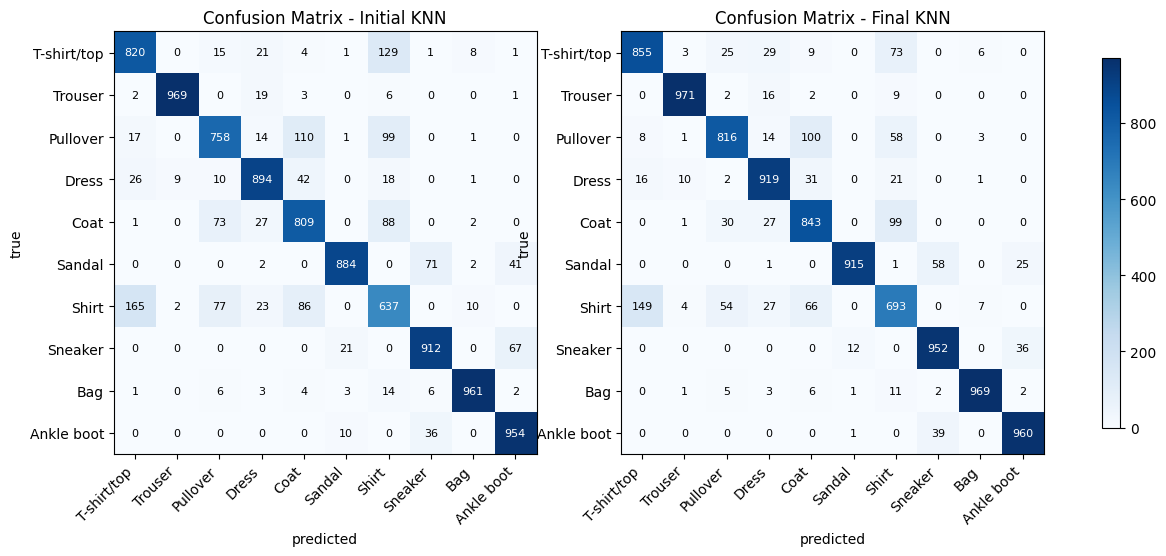

In [ ]:
cm_initial = confusion_matrix(y_test, y_pred)
cm_final = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Initial KNN
im1 = axes[0].imshow(cm_initial, cmap='Blues')

axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(CLASS_NAMES)

axes[0].set_xlabel('predicted')
axes[0].set_ylabel('true')
axes[0].set_title('Confusion Matrix - Initial KNN')

for i in range(10):
    for j in range(10):
        axes[0].text(
            j, i, cm_initial[i, j],
            ha='center',
            va='center',
            color='white' if cm_initial[i, j] > cm_initial.max()/2 else 'black',
            fontsize=8
        )

# Final KNN
im2 = axes[1].imshow(cm_final, cmap='Blues')

axes[1].set_xticks(range(10))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(CLASS_NAMES)

axes[1].set_xlabel('predicted')
axes[1].set_ylabel('true')
axes[1].set_title('Confusion Matrix - Final KNN')

for i in range(10):
    for j in range(10):
        axes[1].text(
            j, i, cm_final[i, j],
            ha='center',
            va='center',
            color='white' if cm_final[i, j] > cm_final.max()/2 else 'black',
            fontsize=8
        )

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.show()

---

###
<div dir="rtl">
<h2>
סיכום
</h2>

בפרויקט זה בנינו מודל KNN מאפס לסיווג תמונות ממאגר Fashion-MNIST. תחילה בנינו flow בסיסי המבוסס על Standardization ו-PCA, ולאחר מכן אימנו והערכנו את המודל באמצעות Macro-F1.

במסגרת ההרחבה השווינו בין ייצוג הפיקסלים הבסיסי לבין HOG, שיטת Feature Engineering ייעודית לתמונות. בנוסף, ביצענו Grid Search עם 5-Fold Cross Validation כדי לבחור בצורה שיטתית את ייצוג התמונה, מספר רכיבי ה-PCA, מספר השכנים k ושיטת ההצבעה. בחנו גם את ההשפעה של כל אחד מהפרמטרים על ביצועי המודל, ובפרט את השפעת k באמצעות עקומת ביצועים.

לבסוף, בחרנו את שילוב הפרמטרים שהשיג את תוצאת ה-Cross Validation הטובה ביותר, אימנו מחדש את המודל על כלל נתוני האימון והערכנו אותו על נתוני ה-test. לאורך העבודה הקפדנו לבצע את שלבי ה-fit על נתוני האימון בלבד, כדי למנוע Data Leakage ולשמור את נתוני ה-test להערכה הסופית של המודל.
</div>